In [1]:
import argparse
import pickle
 
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cmocean as cmc
from matplotlib.colors import ListedColormap

plt.style.use("../plotstyling.mplstyle")

In [2]:
date_str = "2026-06"

with open(f"../data/aws_fwp_band_0.002_0.003_cases_{date_str}.pkl", "rb") as f:
    cases = pickle.load(f)


In [3]:
fwp_min = cases["config"]["fwp_min"]
fwp_max = cases["config"]["fwp_max"]

low = cases["ea_iwp_closest"] < 1e-2        # EarthCARE saw little or no ice
high = cases["ea_iwp_closest"] >= 1e-1


In [4]:
print(f"{len(cases['time'])} cases, AWS FWP from {cases['config']['fwp_min']:g} "
      f"to {cases['config']['fwp_max']:g} kg m-2")
 
# unique dates, with the number of cases on each
dates = pd.DatetimeIndex(cases["time"]).normalize()
counts = dates.value_counts().sort_index()
 
print(f"\n{len(counts)} unique dates:")
for date, n in counts.items():
    print(f"  {date:%Y-%m-%d}: {n}")


1045 cases, AWS FWP from 0.002 to 0.003 kg m-2

9 unique dates:
  2026-06-01: 14
  2026-06-02: 25
  2026-06-03: 37
  2026-06-04: 146
  2026-06-05: 233
  2026-06-06: 235
  2026-06-07: 125
  2026-06-08: 226
  2026-06-09: 4


In [5]:
cases

{'aws_file': array(['l2_arctic_20260601042442_20260601060212_v2.nc',
        'l2_arctic_20260601042442_20260601060212_v2.nc',
        'l2_arctic_20260601042442_20260601060212_v2.nc', ...,
        'l2_arctic_20260609023555_20260609041429_v2.nc',
        'l2_arctic_20260609023555_20260609041429_v2.nc',
        'l2_arctic_20260609023555_20260609041429_v2.nc'],
       shape=(1045,), dtype='<U45'),
 'earthcare_file': array(['ECA_EXBC_ACM_CAP_2B_20260601T043628Z_20260601T080724Z_11409C.h5',
        'ECA_EXBC_ACM_CAP_2B_20260601T043628Z_20260601T080724Z_11409C.h5',
        'ECA_EXBC_ACM_CAP_2B_20260601T043628Z_20260601T080724Z_11409C.h5',
        ...,
        'ECA_EXBC_ACM_CAP_2B_20260609T035212Z_20260609T072234Z_11533C.h5',
        'ECA_EXBC_ACM_CAP_2B_20260609T035212Z_20260609T072234Z_11533C.h5',
        'ECA_EXBC_ACM_CAP_2B_20260609T035212Z_20260609T072234Z_11533C.h5'],
       shape=(1045,), dtype='<U63'),
 'scan_index': array([107, 106, 105, ..., 220, 218, 216], shape=(1045,)),
 'fov_inde

Text(0.5, 1.0, 'Cases with 0.002 <= AWS FWP < 0.003 kg m$^{-2}$ (n=1045)')

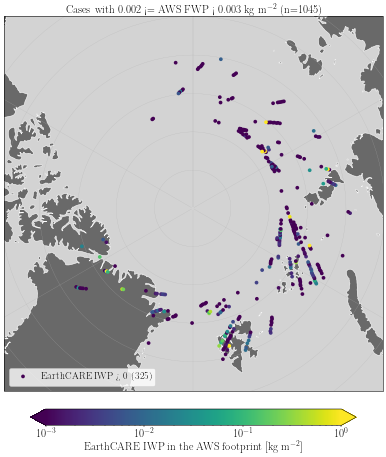

In [6]:
lat = cases["lat"]
lon = cases["lon"]
ea_iwp = cases["ea_iwp_closest"]
clear = ea_iwp <= 0          # EarthCARE saw no ice: cannot go on a log colour scale
 
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(projection=ccrs.NorthPolarStereo())
ax.set_extent([-180, 180, 75, 90], crs=ccrs.PlateCarree())
 
ax.add_feature(cfeature.OCEAN.with_scale("50m"), facecolor="lightgrey", zorder=0)
ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="dimgrey", zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), edgecolor="white", linewidth=0.5, zorder=1)
ax.coastlines(color="white", linewidth=1, zorder=1)
ax.gridlines(draw_labels=False, linewidth=0.3)
 
#ax.scatter(lon[clear], lat[clear], s=12, color="black", ec="none",
#           transform=ccrs.PlateCarree(), zorder=2,
#           label=f"EarthCARE IWP = 0 ({clear.sum()})")
sc = ax.scatter(lon[~clear], lat[~clear], c=ea_iwp[~clear], s=45, ec="none",
                norm=LogNorm(vmin=1e-3, vmax=1e0), cmap="viridis",
                transform=ccrs.PlateCarree(), zorder=3,
                label=f"EarthCARE IWP > 0 ({(~clear).sum()})")
 
fig.colorbar(sc, ax=ax, orientation="horizontal", shrink=0.7, pad=0.04, extend="both",
             label=r"EarthCARE IWP in the AWS footprint [kg m$^{-2}$]")
ax.legend(loc="lower left")
ax.set_title(f"Cases with {fwp_min:g} <= AWS FWP < {fwp_max:g} kg m$^{{-2}}$ "
             f"(n={len(lat)})")
 
#fig_path = Path(args.fig_dir) / f"{Path(args.cases_file).stem}_map.png"
#fig.savefig(fig_path, dpi=200, bbox_inches="tight", facecolor="white")


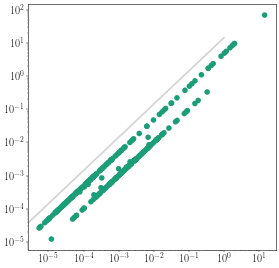

In [7]:
fig, ax = plt.subplots(figsize=(8,8))

iwc_integral = np.trapezoid(cases["ea_iwc"],  x=cases['ea_height'][:, ::-1])

ax.scatter(cases["ea_iwp_closest"], iwc_integral)
ax.plot([np.nanmin(cases["ea_iwp_closest"]), np.nanmax(cases["ea_iwp_closest"])], c="lightgrey")
ax.set_yscale("log")
ax.set_xscale("log")


fraction of cases per surface type (EarthCARE IWP < 1e-2, >= 1e-2):
     ocean:  0.006  0.053
    seaice:  0.420  0.368
      land:  0.063  0.105
     water:  0.000  0.000
      snow:  0.189  0.053
   glacier:  0.076  0.105
     mixed:  0.245  0.316
   missing:  0.000  0.000


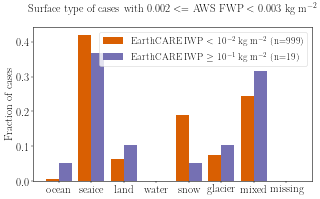

In [8]:
# ============================================================
# SURFACE TYPES
# ============================================================
surface_types = cases["surface_types"]
frac = cases["aws_surface_fractions"]          # (case, surface type)

# a case is the surface with the largest fraction if that fraction is above 0.8,
# otherwise "mixed"; cases with no valid fractions are "missing"
has_frac = np.isfinite(frac).any(axis=1)
frac_filled = np.where(np.isfinite(frac), frac, -1.0)
largest = frac_filled.argmax(axis=1)
largest_frac = frac_filled.max(axis=1)

surface_class = np.where(largest_frac > 0.9,
                         np.array(surface_types)[largest], "mixed")
surface_class[~has_frac] = "missing"

classes = list(surface_types) + ["mixed", "missing"]

counts_low = np.array([np.sum((surface_class == c) & low) for c in classes])
counts_high = np.array([np.sum((surface_class == c) & high) for c in classes])

# each colour sums to 1 over the surface types
frac_low = counts_low / counts_low.sum()
frac_high = counts_high / counts_high.sum()

print("\nfraction of cases per surface type (EarthCARE IWP < 1e-2, >= 1e-2):")
for c, f_low, f_high in zip(classes, frac_low, frac_high):
    print(f"  {c:>8s}: {f_low:6.3f} {f_high:6.3f}")

x = np.arange(len(classes))
width = 0.4

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, frac_low, width, color="C1",
       label=rf"EarthCARE IWP $<$ 10$^{{-2}}$ kg m$^{{-2}}$ (n={counts_low.sum()})")
ax.bar(x + width / 2, frac_high, width, color="C2",
       label=rf"EarthCARE IWP $\geq$ 10$^{{-1}}$ kg m$^{{-2}}$ (n={counts_high.sum()})")


ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel("Fraction of cases")
ax.set_title(f"Surface type of cases with {fwp_min:g} $<=$ AWS FWP $<$ {fwp_max:g} kg m$^{{-2}}$\n")
ax.legend()

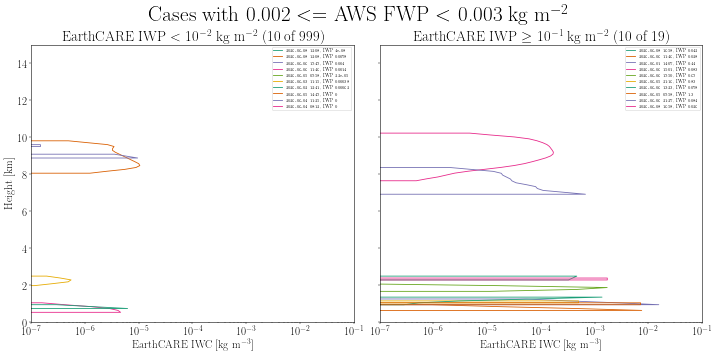

In [9]:
rng = np.random.default_rng(0)   # fixed seed, so the same cases are drawn each time

fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharey=True)

for ax, group, title in [
    (axes[0], low, r"EarthCARE IWP $<$ 10$^{-2}$ kg m$^{-2}$"),
    (axes[1], high, r"EarthCARE IWP $\geq$ 10$^{-1}$ kg m$^{-2}$"),
]:
    idx = np.flatnonzero(group)
    chosen = rng.choice(idx, size=min(10, idx.size), replace=False)

    for i in chosen:
        label = f"{pd.Timestamp(cases['time'][i]):%Y-%m-%d %H:%M}, IWP {cases['ea_iwp'][i]:.2g}"
        ax.plot(cases["ea_iwc"][i], cases["ea_height"][i] / 1000, lw=1.5, label=label)

    ax.set_xscale("log")
    ax.set_xlim(1e-7, 1e-1)
    ax.set_xlabel(r"EarthCARE IWC [kg m$^{-3}$]")
    ax.set_title(f"{title} ({chosen.size} of {idx.size})", fontsize=26)
    ax.legend(fontsize=8, loc="upper right")

axes[0].set_ylim(0, 15)
axes[0].set_ylabel("Height [km]")
fig.suptitle(f"Cases with {fwp_min:g} $<=$ AWS FWP $<$ {fwp_max:g} kg m$^{{-2}}$")
fig.tight_layout()
plt.show()

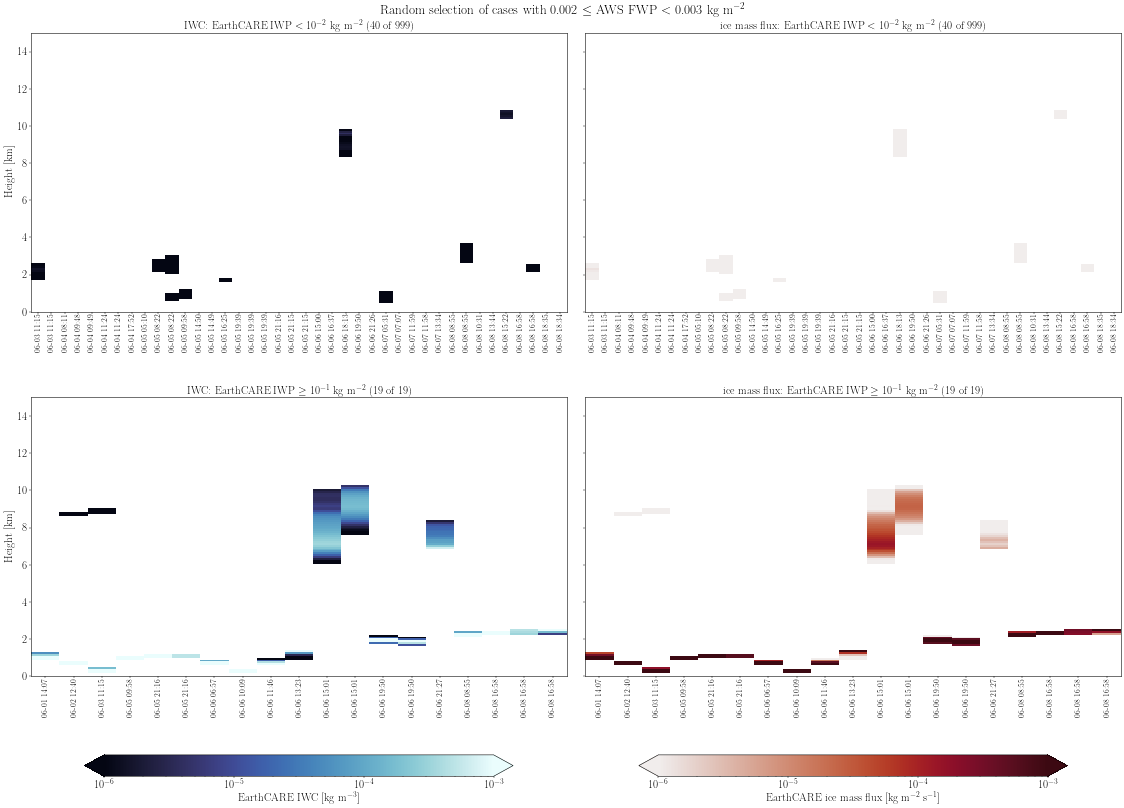

In [15]:

rng = np.random.default_rng(2)   # fixed seed, so the same cases are drawn each time

fig, axes = plt.subplots(2, 2, figsize=(28, 20), sharey=True, layout="constrained")

for row, group, title in [
    (0, low, r"EarthCARE IWP $<$ 10$^{-2}$ kg m$^{-2}$"),
    (1, high, r"EarthCARE IWP $\geq$ 10$^{-1}$ kg m$^{-2}$"),
]:
    idx = np.flatnonzero(group)
    chosen = np.sort(rng.choice(idx, size=min(40, idx.size), replace=False))

    iwc = cases["ea_iwc"][chosen]                   # (case, level)
    flux = cases["ea_ice_mass_flux"][chosen]        # (case, level)
    height = cases["ea_height"][chosen] / 1e3       # (case, level), km
    x_2d = np.broadcast_to(np.arange(chosen.size)[:, None], iwc.shape)

    # left: ice water content
    pm_iwc = axes[row, 0].pcolormesh(x_2d.T, height.T, iwc.T,
                                     shading="nearest", norm=LogNorm(vmin=1e-6, vmax=1e-3),
                                     cmap=cmc.cm.ice)
    # right: ice mass flux, for the same cases
    pm_flux = axes[row, 1].pcolormesh(x_2d.T, height.T, flux.T,
                                      shading="nearest", norm=LogNorm(vmin=1e-6, vmax=1e-3),
                                      cmap=cmc.cm.amp)

    # label each column with the case's time, in both panels
    time_labels = [f"{pd.Timestamp(cases['time'][i]):%m-%d %H:%M}" for i in chosen]
    for col, name in [(0, "IWC"), (1, "ice mass flux")]:
        ax = axes[row, col]
        ax.set_xticks(np.arange(chosen.size))
        ax.set_xticklabels(time_labels, rotation=90, fontsize=14)
        ax.set_title(f"{name}: {title} ({chosen.size} of {idx.size})")

axes[0, 0].set_ylim(0, 15)
axes[0, 0].set_ylabel("Height [km]")
axes[1, 0].set_ylabel("Height [km]")

# one colour bar under each column
fig.colorbar(pm_iwc, ax=axes[:, 0], orientation="horizontal", extend="both", shrink=0.8,
             label=r"EarthCARE IWC [kg m$^{-3}$]")
fig.colorbar(pm_flux, ax=axes[:, 1], orientation="horizontal", extend="both", shrink=0.8,
             label=r"EarthCARE ice mass flux [kg m$^{-2}$ s$^{-1}$]")

fig.suptitle(f"Random selection of cases with {fwp_min:g} $\\leq$ AWS FWP $<$ {fwp_max:g} kg m$^{{-2}}$",
             fontsize=24)

# space between the panels, as a fraction of the figure size
fig.get_layout_engine().set(hspace=0.08, wspace=0.03)

plt.savefig("../figures/aws_band/random_profiles.png",
            facecolor="white", bbox_inches="tight", dpi=200)

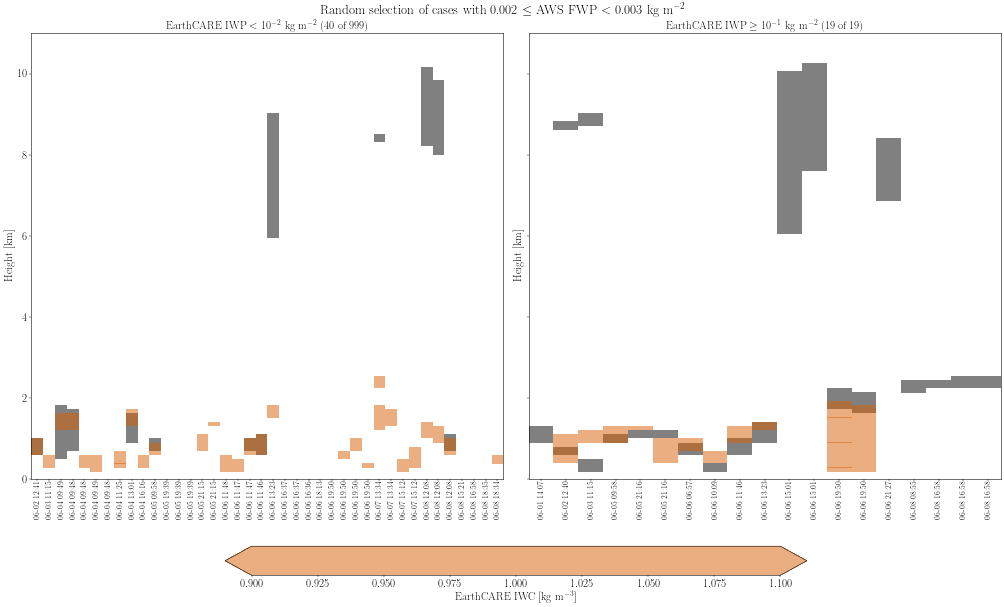

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(25, 15), sharey=True, layout="constrained")

for ax, group, title in [
    (axes[0], low, r"EarthCARE IWP $<$ 10$^{-2}$ kg m$^{-2}$"),
    (axes[1], high, r"EarthCARE IWP $\geq$ 10$^{-1}$ kg m$^{-2}$"),
]:
    idx = np.flatnonzero(group)
    chosen = np.sort(rng.choice(idx, size=min(40, idx.size), replace=False))

    iwc = cases["ea_iwc"][chosen]                   # (case, level)
    lwc = cases["ea_lwc"][chosen]                   # (case, level)
    rwc = cases["ea_rwc"][chosen]                   # (case, level)
    ice_flux = cases["ea_ice_mass_flux"][chosen]                   # (case, level)
    
    height = cases["ea_height"][chosen] / 1e3       # (case, level), km
    x_2d = np.broadcast_to(np.arange(chosen.size)[:, None], iwc.shape)

    has_ice = np.where(iwc > 0, 1.0, np.nan)    # 1 where there is ice, blank elsewhere

    pm = ax.pcolormesh(x_2d.T, height.T, has_ice.T,
                       shading="nearest", cmap=ListedColormap(["grey"]))

    has_liquid = np.where(lwc > 0, 1.0, np.nan)    # 1 where there is liquid, blank elsewhere

    pm = ax.pcolormesh(x_2d.T, height.T, has_liquid.T,
                       shading="nearest", cmap=ListedColormap(["C1"]), alpha=0.5)

    has_rain = np.where(rwc > 0, 1.0, np.nan)    # 1 where there is liquid, blank elsewhere

    #pm = ax.pcolormesh(x_2d.T, height.T, has_rain.T,
    #                   shading="nearest", cmap=ListedColormap(["cornflowerblue"]), alpha=0.5)

    
    # label each column with the case's time
    ax.set_xticks(np.arange(chosen.size))
    ax.set_xticklabels([f"{pd.Timestamp(cases['time'][i]):%m-%d %H:%M}" for i in chosen],
                       rotation=90, fontsize=14)
    ax.set_title(f"{title} ({chosen.size} of {idx.size})")

axes[0].set_ylim(0, 11)
axes[0].set_ylabel("Height [km]")
axes[1].set_ylabel("Height [km]")
fig.colorbar(pm, ax=axes, orientation="horizontal", extend="both", shrink=0.6,
             label=r"EarthCARE IWC [kg m$^{-3}$]")
fig.suptitle(f"Random selection of cases with {fwp_min:g} $\\leq$ AWS FWP $<$ {fwp_max:g} kg m$^{{-2}}$",
             fontsize=24)

# space between the panels, as a fraction of the figure height
fig.get_layout_engine().set(hspace=0.08)

plt.savefig("../figures/aws_band/random_profiles_with lwc.png",
            facecolor="white", bbox_inches="tight", dpi=200)

In [12]:
ice_flux = cases["ea_ice_mass_flux"][chosen]

In [13]:
np.max(ice_flux)

np.float32(0.13230912)